# 03 Boosting Models Trained on Economic Variables

## Objective
Predict whether the FOMC will **raise (Higher)**, **hold (Same)**, or **cut (Lower)** the Federal Funds Rate at each upcoming meeting, using only macroeconomic data available **before** that meeting.

## Pipeline Position

This is the baseline tree-model benchmark on the economic feature table from notebook 02.
It establishes the walk-forward modeling protocol, compares model families and simple
baselines, and provides the tuned-parameter choices reused by the calibrated likelihood
workflow in notebook 04.

**Features used** (all lagged to prevent leakage):
- Lagged upper bound fed funds rate (`target_rate_lag1` to `target_rate_lag4`, plus `lagged_upper_bound`)
- PCE inflation gap (`PCE_inflation_gap_lag1` to `PCE_inflation_gap_lag4`)
- Unemployment gap (`unemployment_gap_lag1` to `unemployment_gap_lag4`)
- Output gap (`output_gap_pct_lag1` to `output_gap_pct_lag4`)
- Financial conditions (`NFCI_lag1` to `NFCI_lag4`)
- Derived change / policy inertia features

## Test Methodology: Walk-Forward (Expanding Window) Validation
For each FOMC meeting at index $t$, starting from `INITIAL_TRAIN_SIZE = 40`:
1. Train on all meetings $[0, t)$
2. Predict meeting $t$
3. Record prediction → advance $t$ by 1

This strictly prevents look-ahead bias — identical to real-world forecasting.

## Models
| Model | Rationale |
|---|---|
| **XGBoost** | L1/L2 regularisation; handles tabular data with strong baseline performance |
| **LightGBM** | Leaf-wise growth; fast and effective for non-linear threshold effects in macro data |
| **CatBoost** | Built-in ordered boosting; useful with small datasets and imbalanced classes |
| **HistGradientBoosting** (sklearn) | Histogram binning; handles feature scale differences natively, no extra deps |

> **Class imbalance note:** most meetings are still "Same".
> All models use balanced class weights where supported. **F1 Macro** is the primary evaluation metric.


In [1]:
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, recall_score
)
from sklearn.ensemble import HistGradientBoostingClassifier

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'analysis':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from modeling.catboost_artifacts import (
    catboost_artifact_available,
    load_03_boosting_artifact,
    load_03_study_proxy,
)
from modeling.notebook_io import resolve_data_source

# ── Optional packages ─────────────────────────────────────────────────────────
try:
    import xgboost as xgb
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print(f'XGBoost {xgb.__version__} loaded')
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not found – run: pip install xgboost')

try:
    import lightgbm as lgb
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
    print(f'LightGBM {lgb.__version__} loaded')
except ImportError:
    LGBM_AVAILABLE = False
    print('LightGBM not found – run: pip install lightgbm')

CATBOOST_AVAILABLE = catboost_artifact_available(PROJECT_ROOT, '03_boosting.json')
catboost_bundle_03 = load_03_boosting_artifact(PROJECT_ROOT) if CATBOOST_AVAILABLE else None

if CATBOOST_AVAILABLE:
    print('CatBoost artifacts loaded (analysis mode)')
else:
    print('CatBoost artifacts not found – run: python scripts/build_catboost_artifacts.py')

print('sklearn HistGradientBoostingClassifier: available')

XGBoost 3.2.0 loaded


LightGBM 4.6.0 loaded
CatBoost artifacts loaded (analysis mode)
sklearn HistGradientBoostingClassifier: available


In [2]:
# ── Load the pre-processed model DataFrame ────────────────────────────────────
DATA_URL = resolve_data_source('df_model.csv', PROJECT_ROOT)
df_model = pd.read_csv(DATA_URL, parse_dates=['meeting_date'])

print(f'Loaded df_model from {DATA_URL}: {df_model.shape[0]} rows × {df_model.shape[1]} columns')
print(f'Date range : {df_model["meeting_date"].min().date()} → {df_model["meeting_date"].max().date()}')
display(df_model.head())


Loaded df_model from /Users/echohuang/Documents/forecasting_fed_rate/data/df_model.csv: 136 rows × 32 columns
Date range : 2009-08-12 → 2026-01-28


,meeting_date,decision,decision_num,target_rate_lag1,target_rate_lag2,target_rate_lag3,target_rate_lag4,PCE_inflation_gap_lag1,PCE_inflation_gap_lag2,PCE_inflation_gap_lag3,...,NFCI_lag4,lagged_upper_bound,PCE_gap_change_1m,unemployment_gap_change_1m,output_gap_change_1q,nfci_change_1m,prev_decision,prev_decision_num,time_since_last_change,consecutive_same
0,2009-08-12,same,0.0,0.25,0.25,0.25,0.25,-3.018625,-2.567574,-2.525752,...,2.308464,0.25,-0.451051,0.501559,0.019935,-0.811965,same,0.0,3,3
1,2009-09-23,same,0.0,0.25,0.25,0.25,0.25,-3.100120,-3.018625,-2.567574,...,2.044215,0.25,-0.081495,0.101831,0.254070,-0.483890,same,0.0,4,4
2,2009-11-04,same,0.0,0.25,0.25,0.25,0.25,-3.022749,-3.100120,-3.018625,...,1.584693,0.25,0.077371,0.201051,0.244102,-0.140380,same,0.0,5,5
3,2009-12-16,same,0.0,0.25,0.25,0.25,0.25,-0.539388,-3.022749,-3.100120,...,0.772728,0.25,2.483361,0.102399,0.298995,-0.156645,same,0.0,6,6
4,2010-01-27,same,0.0,0.25,0.25,0.25,0.25,0.089718,-0.539388,-3.022749,...,0.288838,0.25,0.629106,0.001348,0.054893,-0.095175,same,0.0,7,7


In [3]:
# ── Feature / Label Setup ─────────────────────────────────────────────────────

# Columns that are NOT predictive features
NON_FEATURE_COLS = ['meeting_date', 'decision', 'decision_num', 'prev_decision']
feature_cols = [c for c in df_model.columns if c not in NON_FEATURE_COLS]

X = df_model[feature_cols].values.astype(float)
y_orig = df_model['decision_num'].values.astype(int) # -1, 0, 1
meeting_dates = df_model['meeting_date'].values

# XGBoost / LightGBM / CatBoost require 0-indexed integer labels
LABEL_MAP     = {-1: 0,  0: 1,  1: 2}  # original → encoded
INV_LABEL_MAP = { 0: -1, 1: 0,  2: 1}  # encoded  → original
CLASS_NAMES   = {-1: 'Lower', 0: 'Same', 1: 'Higher'}
ENCODED_NAMES = { 0: 'Lower', 1: 'Same', 2: 'Higher'}
LABEL_VALS    = [-1, 0, 1]
LABEL_STRS    = ['Lower', 'Same', 'Higher']

y_enc = np.array([LABEL_MAP[v] for v in y_orig])   # 0, 1, 2

print(f'Features ({len(feature_cols)}):')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i:2d}. {col}')

print()
print('Class distribution:')
for v in [-1, 0, 1]:
    n = (y_orig == v).sum()
    print(f'  {CLASS_NAMES[v]:7s} ({v:+d}): {n:3d}  ({n/len(y_orig)*100:.1f}%)')

Features (28):
   1. target_rate_lag1
   2. target_rate_lag2
   3. target_rate_lag3
   4. target_rate_lag4
   5. PCE_inflation_gap_lag1
   6. PCE_inflation_gap_lag2
   7. PCE_inflation_gap_lag3
   8. PCE_inflation_gap_lag4
   9. unemployment_gap_lag1
  10. unemployment_gap_lag2
  11. unemployment_gap_lag3
  12. unemployment_gap_lag4
  13. output_gap_pct_lag1
  14. output_gap_pct_lag2
  15. output_gap_pct_lag3
  16. output_gap_pct_lag4
  17. NFCI_lag1
  18. NFCI_lag2
  19. NFCI_lag3
  20. NFCI_lag4
  21. lagged_upper_bound
  22. PCE_gap_change_1m
  23. unemployment_gap_change_1m
  24. output_gap_change_1q
  25. nfci_change_1m
  26. prev_decision_num
  27. time_since_last_change
  28. consecutive_same

Class distribution:
  Lower   (-1):  11  (8.1%)
  Same    (+0): 105  (77.2%)
  Higher  (+1):  20  (14.7%)


## Walk-Forward Validation Infrastructure

```
Train on [0 … t-1]  →  Predict meeting t  →  t += 1
```

- `INITIAL_TRAIN_SIZE = 40` — keeps the first training windows large enough for a stable expanding-window baseline
- First rate **hike** appears at df_model row 50 (2015-12-16)
- First rate **cut** appears at df_model row 79 (2019-07-31)

> For meetings 40–49, training data contains only *Same* decisions.
> Models cannot predict a class they have never seen — this reflects real-world constraints.
> A synthetic near-zero-weight sample is injected for missing classes so XGBoost never crashes.


In [4]:
INITIAL_TRAIN_SIZE = 40


def augment_missing_classes(X_train, y_train, all_classes=(0, 1, 2)):
    """
    Inject one synthetic sample per missing class (mean features, low weight).
    Returns (X_aug, y_aug, sample_weights).
    """
    present = set(y_train)
    missing = set(all_classes) - present

    class_counts = np.bincount(y_train, minlength=3)
    n_total      = len(y_train)
    # Inverse-frequency weights for real samples
    real_weights = np.array([n_total / (3 * max(class_counts[c], 1)) for c in y_train],
                             dtype=float)

    if not missing:
        return X_train, y_train, real_weights

    X_mean       = X_train.mean(axis=0, keepdims=True)
    X_synth      = np.vstack([X_mean] * len(missing))
    y_synth      = np.array(sorted(missing))
    synth_weight = float(real_weights.min()) * 0.1
    w_synth      = np.full(len(missing), synth_weight, dtype=float)

    X_aug = np.vstack([X_train, X_synth])
    y_aug = np.concatenate([y_train, y_synth])
    w_aug = np.concatenate([real_weights, w_synth])
    return X_aug, y_aug, w_aug


def walk_forward_eval(fit_fn, predict_fn, X, y_enc,
                      n_start=INITIAL_TRAIN_SIZE, verbose=True):
    """
    Expanding-window walk-forward evaluation.
    Returns actuals_enc, preds_enc (both in {0,1,2} encoded space).
    """
    actuals, preds = [], []
    total = len(X) - n_start

    for t in range(n_start, len(X)):
        X_train, y_train = X[:t], y_enc[:t]
        X_test           = X[t:t+1]

        model = fit_fn(X_train, y_train)
        pred  = predict_fn(model, X_test)

        actuals.append(y_enc[t])
        preds.append(pred)

        done = t - n_start + 1
        if verbose and (done % 25 == 0 or done == total):
            true_label = ENCODED_NAMES[y_enc[t]]
            pred_label = ENCODED_NAMES[pred]
            flag = '✓' if y_enc[t] == pred else '✗'
            print(f'  [{done:3d}/{total}] {df_model["meeting_date"].iloc[t].date()}'
                  f'  true={true_label:7s}  pred={pred_label:7s}  {flag}')

    return np.array(actuals), np.array(preds)


def report_metrics(name, actuals_enc, preds_enc):
    """Print metrics and return results dict with both encoded & original labels."""
    act  = np.array([INV_LABEL_MAP[a] for a in actuals_enc])
    pred = np.array([INV_LABEL_MAP[p] for p in preds_enc])

    acc     = accuracy_score(act, pred)
    f1_mac  = f1_score(act, pred, labels=LABEL_VALS, average='macro',    zero_division=0)
    f1_wt   = f1_score(act, pred, labels=LABEL_VALS, average='weighted', zero_division=0)
    n_test  = len(act)
    n_right = int(acc * n_test)

    print('=' * 58)
    print(f'  {name}')
    print('=' * 58)
    print(f'  Accuracy   : {acc:.4f}  ({n_right}/{n_test} correct)')
    print(f'  F1 Macro   : {f1_mac:.4f}  (primary metric)')
    print(f'  F1 Weighted: {f1_wt:.4f}')
    print()
    print(classification_report(act, pred, labels=LABEL_VALS,
                                 target_names=LABEL_STRS, zero_division=0))
    return dict(name=name, accuracy=acc, f1_macro=f1_mac, f1_weighted=f1_wt,
                actuals_enc=actuals_enc, preds_enc=preds_enc,
                actuals_orig=act, preds_orig=pred)


all_results = {}   # populated as each model runs
print('Walk-forward infrastructure ready.')
print(f'  Training starts at row {INITIAL_TRAIN_SIZE} '
      f'({df_model["meeting_date"].iloc[INITIAL_TRAIN_SIZE].date()})')
print(f'  Out-of-sample predictions: {len(X) - INITIAL_TRAIN_SIZE}')

Walk-forward infrastructure ready.
  Training starts at row 40 (2014-07-30)
  Out-of-sample predictions: 96


---
## Model 1 — XGBoost

**Why XGBoost for FOMC prediction?**
- **L1 (alpha) + L2 (lambda) regularisation** prevents overfitting on our small dataset (~40–135 training meetings).
- **Inverse-frequency sample weights** correct for class imbalance (77 % Same, 15 % Higher, 8 % Lower).
- **`gamma` (min split loss)** further controls tree complexity.
- Missing-class injection ensures the model never crashes when early windows lack a rate change.

**Key hyperparameters**
| Param | Value | Rationale |
|---|---|---|
| `max_depth` | 3 | Shallow trees prevent overfitting on tabular time-series |
| `n_estimators` | 100 | Enough boosting rounds for the default lightweight comparison run |
| `learning_rate` | 0.03 | Conservative step; combined with 300 rounds |
| `subsample / colsample_bytree` | 0.8 / 0.8 | Stochastic boosting reduces variance |
| `min_child_weight` | 3 | Prevents splits on tiny leaf samples |
| `gamma` | 1.0 | Minimum gain required to make a split |


In [5]:
if XGBOOST_AVAILABLE:
    t0 = time.time()
    print('Running XGBoost walk-forward validation …')

    def xgb_fit(X_train, y_train):
        X_aug, y_aug, sw = augment_missing_classes(X_train, y_train)
        model = XGBClassifier(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=3,
            gamma=1.0,
            reg_alpha=0.5,
            reg_lambda=1.5,
            objective='multi:softmax',
            num_class=3,
            random_state=42,
            verbosity=0,
            n_jobs=1,
        )
        model.fit(X_aug, y_aug, sample_weight=sw)
        return model

    def xgb_predict(model, X_test):
        return int(model.predict(X_test)[0])

    act_xgb, pred_xgb = walk_forward_eval(xgb_fit, xgb_predict, X, y_enc)
    print(f'\nTotal time: {time.time()-t0:.1f}s')
    results_xgb = report_metrics('XGBoost', act_xgb, pred_xgb)
    all_results['XGBoost'] = results_xgb
else:
    print('XGBoost not available – skipping.')
    results_xgb = None

Running XGBoost walk-forward validation …


  [ 25/96] 2017-07-26  true=Same     pred=Higher   ✗


  [ 50/96] 2020-04-29  true=Same     pred=Same     ✓


  [ 75/96] 2023-06-14  true=Same     pred=Higher   ✗


  [ 96/96] 2026-01-28  true=Same     pred=Lower    ✗

Total time: 2.9s
  XGBoost
  Accuracy   : 0.5625  (54/96 correct)
  F1 Macro   : 0.5330  (primary metric)
  F1 Weighted: 0.5879

              precision    recall  f1-score   support

       Lower       0.39      0.64      0.48        11
        Same       0.91      0.49      0.64        65
      Higher       0.35      0.75      0.48        20

    accuracy                           0.56        96
   macro avg       0.55      0.63      0.53        96
weighted avg       0.74      0.56      0.59        96



---
## Model 2 — LightGBM

**Why LightGBM for FOMC prediction?**
- **Leaf-wise tree growth** (vs depth-wise) captures asymmetric non-linearities — e.g., inflation-gap or labor-slack thresholds can trigger very different Fed behaviour than gradual moves.
- The default gradient-boosted tree setup is kept simple and reproducible; class weighting handles the dominant Same class.
- `class_weight='balanced'` automatically adjusts weights proportional to inverse class frequency.
- `min_child_samples=5` guards against micro-splits on rare Lower / Higher observations.

**Key hyperparameters**
| Param | Value | Rationale |
|---|---|---|
| `num_leaves` | 15 | Controls leaf-wise tree complexity |
| `n_estimators` | 100 | Same boosting-round count as the default XGBoost run |
| `learning_rate` | 0.03 | Low LR + many rounds |
| `min_child_samples` | 5 | Prevents overfitting on scarce minority classes |
| `class_weight` | `'balanced'` | Automatic inverse-frequency weighting |


In [6]:
if LGBM_AVAILABLE:
    t0 = time.time()
    print('Running LightGBM walk-forward validation …')

    def lgbm_fit(X_train, y_train):
        model = LGBMClassifier(
            n_estimators=100,
            num_leaves=15,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_samples=5,
            reg_alpha=0.5,
            reg_lambda=1.5,
            class_weight='balanced',
            random_state=42,
            verbose=-1,
            n_jobs=1,
        )
        model.fit(X_train, y_train)
        return model

    def lgbm_predict(model, X_test):
        return int(model.predict(X_test)[0])

    act_lgbm, pred_lgbm = walk_forward_eval(lgbm_fit, lgbm_predict, X, y_enc)
    print(f'\nTotal time: {time.time()-t0:.1f}s')
    results_lgbm = report_metrics('LightGBM', act_lgbm, pred_lgbm)
    all_results['LightGBM'] = results_lgbm
else:
    print('LightGBM not available – skipping.')
    results_lgbm = None

Running LightGBM walk-forward validation …


  [ 25/96] 2017-07-26  true=Same     pred=Higher   ✗


  [ 50/96] 2020-04-29  true=Same     pred=Same     ✓


  [ 75/96] 2023-06-14  true=Same     pred=Higher   ✗


  [ 96/96] 2026-01-28  true=Same     pred=Lower    ✗

Total time: 1.9s
  LightGBM
  Accuracy   : 0.6458  (62/96 correct)
  F1 Macro   : 0.5710  (primary metric)
  F1 Weighted: 0.6602

              precision    recall  f1-score   support

       Lower       0.38      0.45      0.42        11
        Same       0.84      0.65      0.73        65
      Higher       0.45      0.75      0.57        20

    accuracy                           0.65        96
   macro avg       0.56      0.62      0.57        96
weighted avg       0.71      0.65      0.66        96



---
## Model 3 — CatBoost

CatBoost execution has been moved out of this notebook.
This notebook now loads CatBoost walk-forward results, tuning summaries, and
latest-meeting probabilities from `artifacts/catboost/03_boosting.json`.

In [7]:
if CATBOOST_AVAILABLE:
    print('Loading CatBoost walk-forward validation from artifacts …')
    act_cat = catboost_bundle_03['default_result']['actuals_enc']
    pred_cat = catboost_bundle_03['default_result']['preds_enc']
    results_cat = report_metrics('CatBoost', act_cat, pred_cat)
    all_results['CatBoost'] = results_cat
else:
    print('CatBoost artifacts not available – skipping.')


Loading CatBoost walk-forward validation from artifacts …
  CatBoost
  Accuracy   : 0.6042  (58/96 correct)
  F1 Macro   : 0.5890  (primary metric)
  F1 Weighted: 0.6178

              precision    recall  f1-score   support

       Lower       0.47      0.73      0.57        11
        Same       0.89      0.51      0.65        65
      Higher       0.40      0.85      0.55        20

    accuracy                           0.60        96
   macro avg       0.59      0.69      0.59        96
weighted avg       0.74      0.60      0.62        96



---
## Model 4 — HistGradientBoosting (sklearn)

**Why HistGradientBoosting for FOMC prediction?**
- Histogram-based binning (inspired by LightGBM) — **no extra installation** required.
- Natively handles missing values, which may appear during very early walk-forward windows.
- `class_weight='balanced'` and `min_samples_leaf` provide out-of-the-box imbalance handling.
- Provides a strong sklearn-native baseline to compare against the specialised libraries.

**Key hyperparameters**
| Param | Value | Rationale |
|---|---|---|
| `max_iter` | 150 | Boosting rounds in the default lightweight comparison run |
| `max_depth` | 4 | Slightly deeper; HGB uses leaf-wise internally |
| `learning_rate` | 0.03 | Same as others |
| `min_samples_leaf` | 5 | Guards against micro-leaf splits |
| `l2_regularization` | 1.0 | Regularisation term |
| `class_weight` | `'balanced'` | Automatic inverse-frequency weighting |


In [8]:
t0 = time.time()
print('Running HistGradientBoosting walk-forward validation …')

def hgb_fit(X_train, y_train):
    model = HistGradientBoostingClassifier(
        max_iter=150,
        max_depth=4,
        learning_rate=0.03,
        min_samples_leaf=5,
        l2_regularization=1.0,
        class_weight='balanced',
        random_state=42,
    )
    model.fit(X_train, y_train)
    return model

def hgb_predict(model, X_test):
    return int(model.predict(X_test)[0])

act_hgb, pred_hgb = walk_forward_eval(hgb_fit, hgb_predict, X, y_enc)
print(f'\nTotal time: {time.time()-t0:.1f}s')
results_hgb = report_metrics('HistGradientBoosting (sklearn)', act_hgb, pred_hgb)
all_results['HistGradientBoosting'] = results_hgb

Running HistGradientBoosting walk-forward validation …


  [ 25/96] 2017-07-26  true=Same     pred=Same     ✓


  [ 50/96] 2020-04-29  true=Same     pred=Same     ✓


  [ 75/96] 2023-06-14  true=Same     pred=Higher   ✗


  [ 96/96] 2026-01-28  true=Same     pred=Same     ✓

Total time: 73.4s
  HistGradientBoosting (sklearn)
  Accuracy   : 0.6771  (65/96 correct)
  F1 Macro   : 0.5458  (primary metric)
  F1 Weighted: 0.6702

              precision    recall  f1-score   support

       Lower       0.50      0.27      0.35        11
        Same       0.76      0.78      0.77        65
      Higher       0.48      0.55      0.51        20

    accuracy                           0.68        96
   macro avg       0.58      0.54      0.55        96
weighted avg       0.67      0.68      0.67        96



---
## Baselines

Two naive baselines are recomputed on the same walk-forward window for comparison:
- **Majority Class Baseline**: Always predicts the most common class seen so far.
- **Last Decision Baseline**: Predicts whatever the previous meeting decided (regime persistence).


In [9]:
print('Computing baselines …')

preds_majority, preds_last = [], []
for t in range(INITIAL_TRAIN_SIZE, len(y_enc)):
    hist = y_enc[:t]
    preds_majority.append(int(pd.Series(hist).mode()[0]))
    preds_last.append(int(hist[-1]))

act_base = y_enc[INITIAL_TRAIN_SIZE:]

results_majority = report_metrics('Majority Class Baseline',
                                   act_base, np.array(preds_majority))
results_last     = report_metrics('Last Decision Baseline',
                                   act_base, np.array(preds_last))

all_results['Majority Baseline'] = results_majority
all_results['Last Decision Baseline'] = results_last

Computing baselines …
  Majority Class Baseline
  Accuracy   : 0.6771  (65/96 correct)
  F1 Macro   : 0.2692  (primary metric)
  F1 Weighted: 0.5467

              precision    recall  f1-score   support

       Lower       0.00      0.00      0.00        11
        Same       0.68      1.00      0.81        65
      Higher       0.00      0.00      0.00        20

    accuracy                           0.68        96
   macro avg       0.23      0.33      0.27        96
weighted avg       0.46      0.68      0.55        96

  Last Decision Baseline
  Accuracy   : 0.6667  (64/96 correct)
  F1 Macro   : 0.5831  (primary metric)
  F1 Weighted: 0.6667

              precision    recall  f1-score   support

       Lower       0.55      0.55      0.55        11
        Same       0.75      0.75      0.75        65
      Higher       0.45      0.45      0.45        20

    accuracy                           0.67        96
   macro avg       0.58      0.58      0.58        96
weighted avg    

---
## Model Comparison

In [10]:
# ── Summary Table ─────────────────────────────────────────────────────────────
display_order = [
    'XGBoost', 'LightGBM', 'CatBoost', 'HistGradientBoosting',
    'Majority Baseline', 'Last Decision Baseline'
]

rows = []
for name in display_order:
    if name not in all_results:
        continue
    r = all_results[name]
    n_test  = len(r['actuals_orig'])
    n_right = int(r['accuracy'] * n_test)
    rows.append({
        'Model'        : r['name'],
        'Accuracy'     : round(r['accuracy'],    4),
        'Correct/Total': f'{n_right}/{n_test}',
        'F1 Macro'     : round(r['f1_macro'],    4),
        'F1 Weighted'  : round(r['f1_weighted'], 4),
        'Type'         : 'Boosting' if name not in ('Majority Baseline', 'Last Decision Baseline') else 'Baseline',
    })

df_comp = pd.DataFrame(rows)

print('=' * 70)
print('  MODEL PERFORMANCE COMPARISON')
print(f'  Walk-forward on {len(act_base)} out-of-sample FOMC meetings')
print(f'  Primary metric: F1 Macro (balanced across Lower / Same / Higher)')
print('=' * 70)
display(df_comp.sort_values('F1 Macro', ascending=False).reset_index(drop=True))

  MODEL PERFORMANCE COMPARISON
  Walk-forward on 96 out-of-sample FOMC meetings
  Primary metric: F1 Macro (balanced across Lower / Same / Higher)


,Model,Accuracy,Correct/Total,F1 Macro,F1 Weighted,Type
0,CatBoost,0.6042,58/96,0.5890,0.6178,Boosting
1,Last Decision Baseline,0.6667,64/96,0.5831,0.6667,Baseline
2,LightGBM,0.6458,62/96,0.5710,0.6602,Boosting
3,HistGradientBoosting (sklearn),0.6771,65/96,0.5458,0.6702,Boosting
4,XGBoost,0.5625,54/96,0.5330,0.5879,Boosting
5,Majority Class Baseline,0.6771,65/96,0.2692,0.5467,Baseline


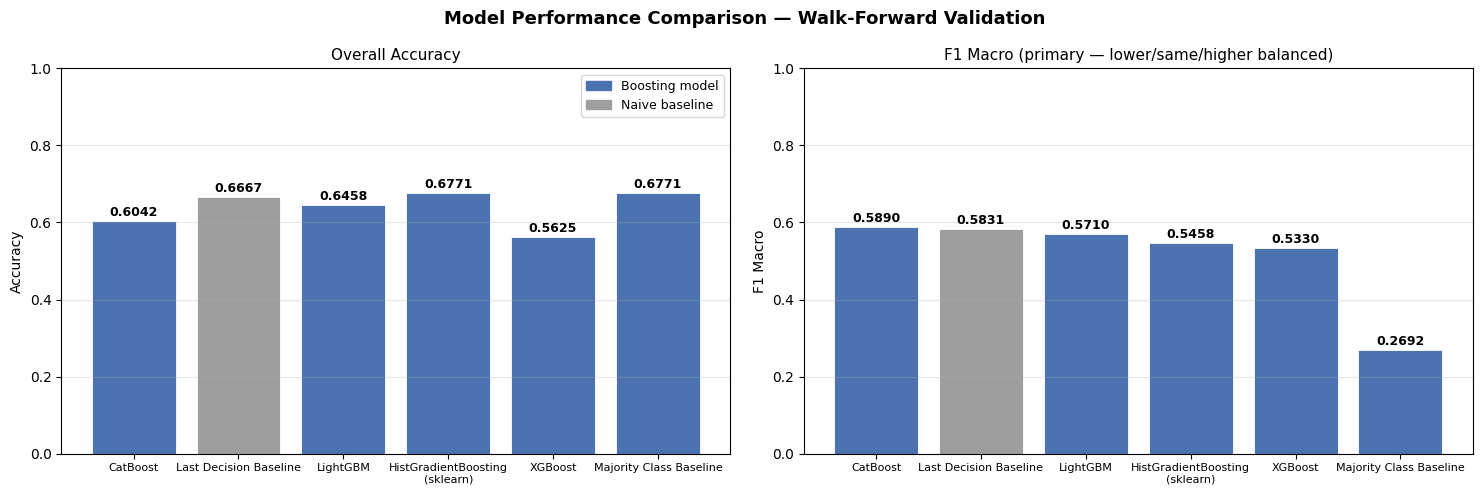

In [11]:
# ── Accuracy & F1 Macro Bar Charts ────────────────────────────────────────────
ordered = sorted(all_results.values(), key=lambda r: r['f1_macro'], reverse=True)
names   = [r['name'].replace(' (sklearn)', '\n(sklearn)') for r in ordered]
is_boost = [r['name'] not in ('Majority Baseline', 'Last Decision Baseline')
            for r in ordered]

BOOST_COLOR    = '#4C72B0'
BASELINE_COLOR = '#9e9e9e'

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, metric, title in [
    (axes[0], 'accuracy',  'Overall Accuracy'),
    (axes[1], 'f1_macro',  'F1 Macro (primary — lower/same/higher balanced)'),
]:
    vals   = [r[metric] for r in ordered]
    colors = [BOOST_COLOR if b else BASELINE_COLOR for b in is_boost]
    bars   = ax.bar(names, vals, color=colors, edgecolor='white', linewidth=0.6)

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_ylim(0, 1.0)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(True, alpha=0.3, axis='y')

from matplotlib.patches import Patch
legend_handles = [
    Patch(color=BOOST_COLOR,    label='Boosting model'),
    Patch(color=BASELINE_COLOR, label='Naive baseline'),
]
axes[0].legend(handles=legend_handles, fontsize=9)

plt.suptitle('Model Performance Comparison — Walk-Forward Validation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

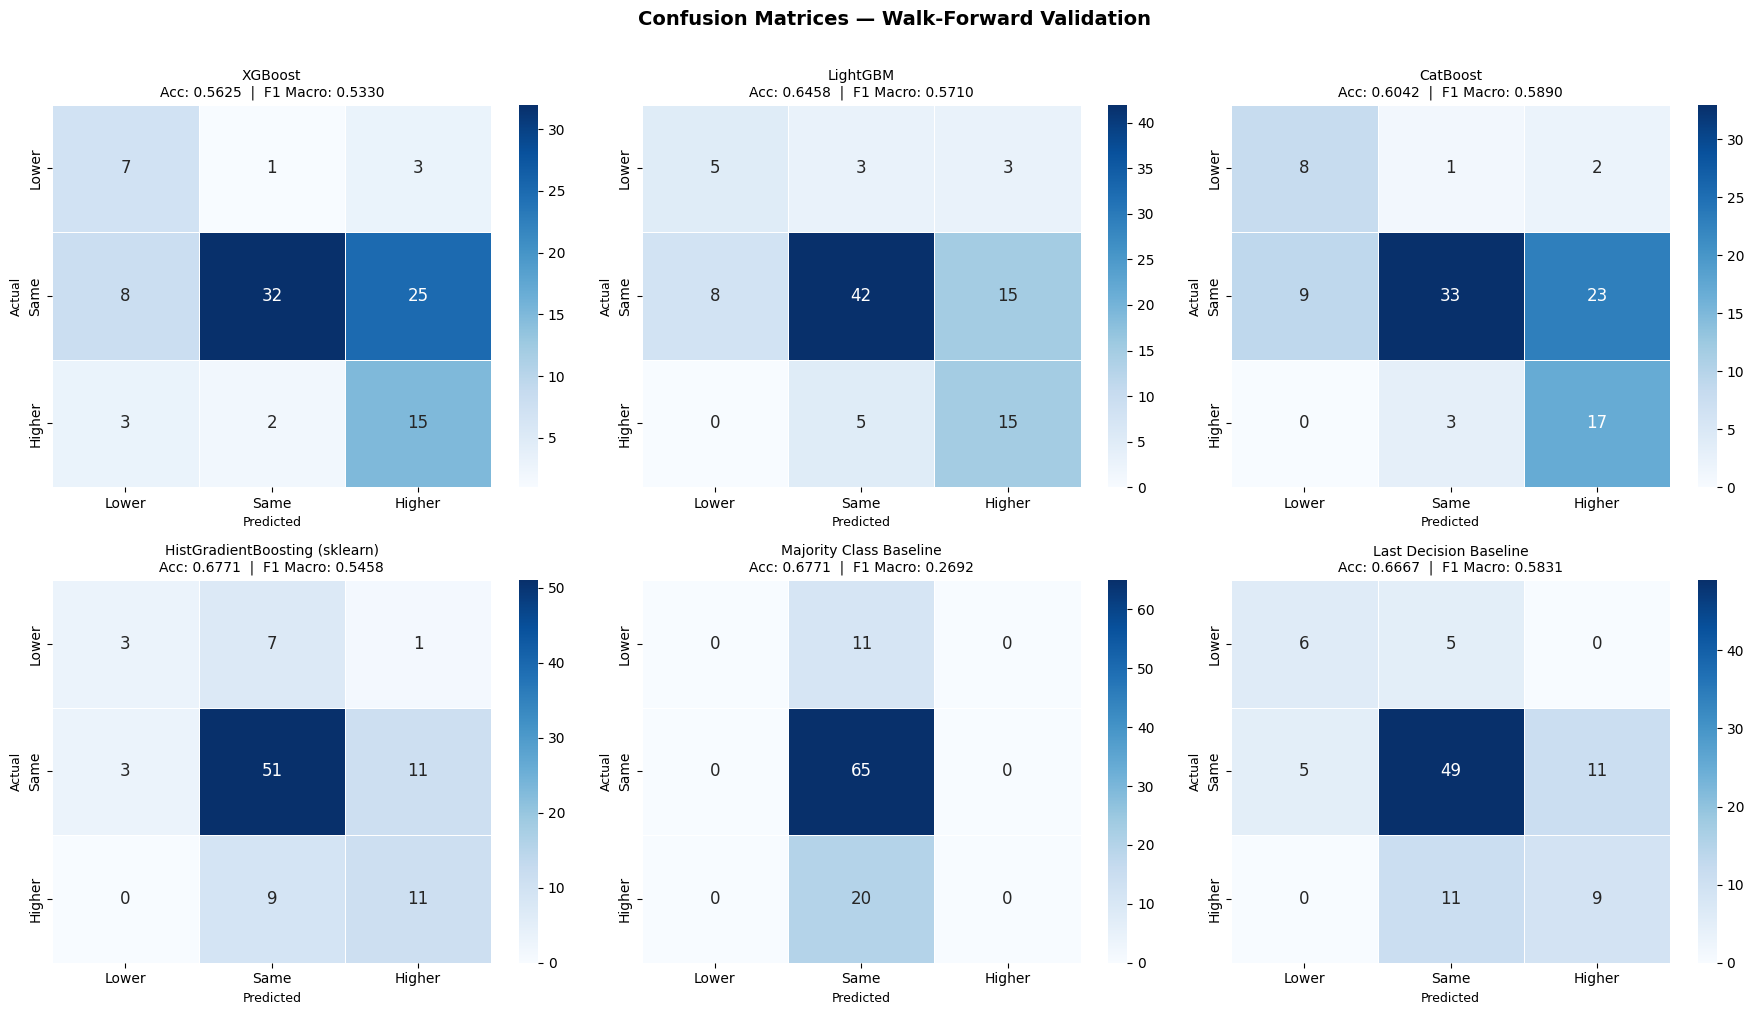

In [12]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
n_models = len(all_results)
ncols    = 3
nrows    = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for ax_i, (name, r) in enumerate(all_results.items()):
    cm = confusion_matrix(r['actuals_orig'], r['preds_orig'], labels=LABEL_VALS)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABEL_STRS, yticklabels=LABEL_STRS,
                ax=axes[ax_i], linewidths=0.5, linecolor='white',
                annot_kws={'size': 12})
    axes[ax_i].set_title(
        f'{r["name"]}\n'
        f'Acc: {r["accuracy"]:.4f}  |  F1 Macro: {r["f1_macro"]:.4f}',
        fontsize=10
    )
    axes[ax_i].set_xlabel('Predicted', fontsize=9)
    axes[ax_i].set_ylabel('Actual',    fontsize=9)

for ax_i in range(len(all_results), len(axes)):
    axes[ax_i].set_visible(False)

plt.suptitle('Confusion Matrices — Walk-Forward Validation',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

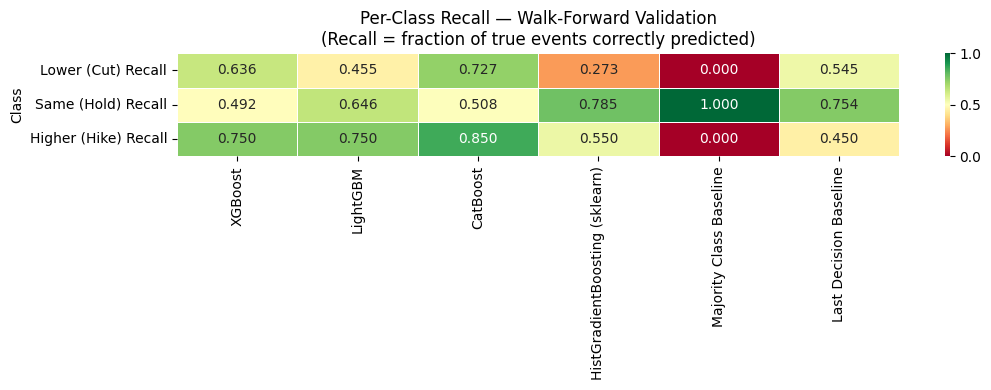

Interpretation:
  Lower (Cut) recall: Critical — missing a rate cut is costly for rate-sensitive portfolios.
  Higher (Hike) recall: Important — missing a hike means under-pricing interest rate risk.
  Same (Hold) recall: Easy — naive models already do well here due to class dominance.


In [13]:
# ── Per-Class Recall Heatmap ──────────────────────────────────────────────────
# Recall answers: "Of all real X meetings, how many did the model catch?"
recall_rows = []
for name, r in all_results.items():
    rec = recall_score(r['actuals_orig'], r['preds_orig'],
                       labels=LABEL_VALS, average=None, zero_division=0)
    recall_rows.append({
        'Model' : r['name'],
        'Lower (Cut) Recall' : rec[0],
        'Same (Hold) Recall' : rec[1],
        'Higher (Hike) Recall': rec[2],
    })

df_recall = pd.DataFrame(recall_rows).set_index('Model')

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(df_recall.T, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white',
            vmin=0, vmax=1, ax=ax, annot_kws={'size': 10})
ax.set_title('Per-Class Recall — Walk-Forward Validation\n'
             '(Recall = fraction of true events correctly predicted)', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('Class', fontsize=10)
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  Lower (Cut) recall: Critical — missing a rate cut is costly for rate-sensitive portfolios.')
print('  Higher (Hike) recall: Important — missing a hike means under-pricing interest rate risk.')
print('  Same (Hold) recall: Easy — naive models already do well here due to class dominance.')

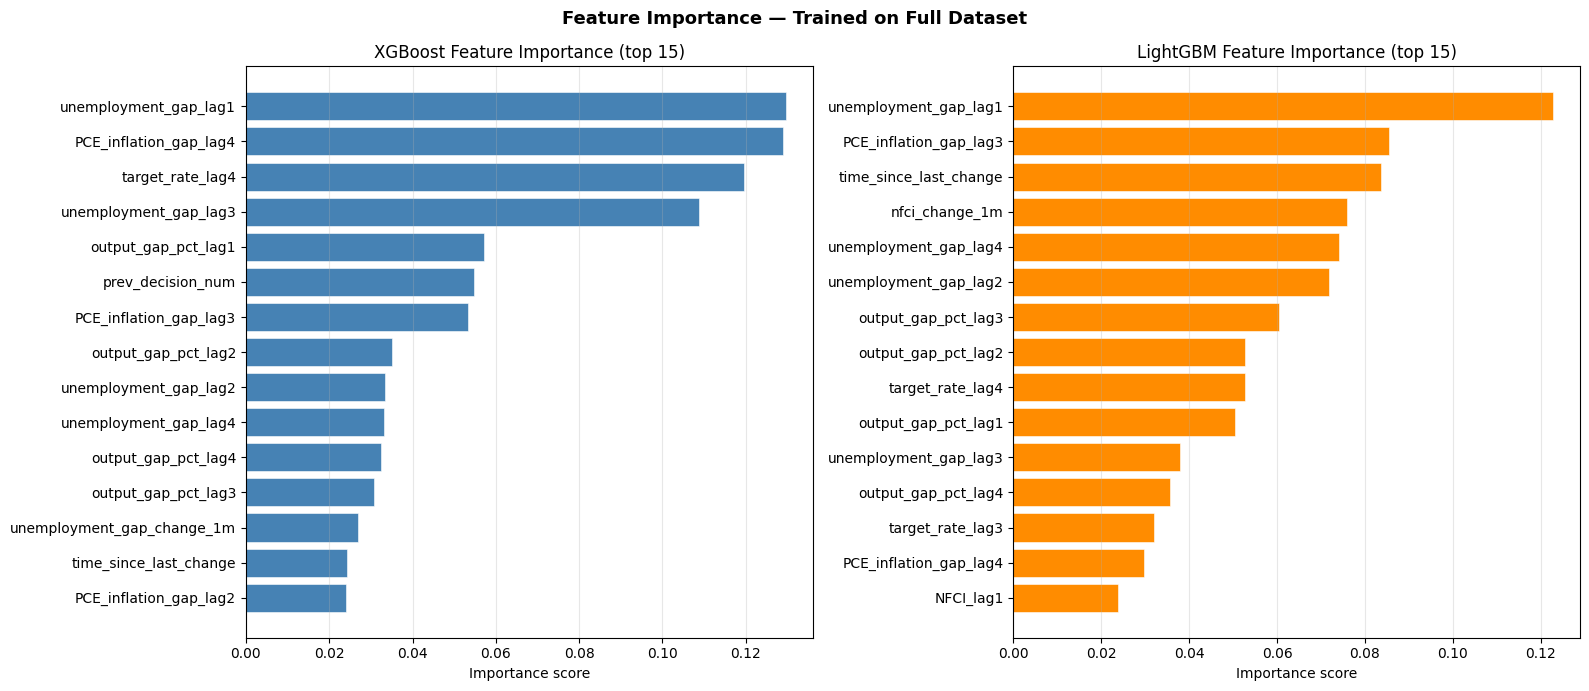

In [14]:
# ── Feature Importance (XGBoost + LightGBM) ───────────────────────────────────
# Trained on the FULL dataset for global importance (not per walk-forward window)
TOP_N = 15

available_models = {}

if XGBOOST_AVAILABLE:
    X_aug_full, y_aug_full, sw_full = augment_missing_classes(X, y_enc)
    xgb_global = XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.03,
        objective='multi:softmax', num_class=3,
        random_state=42, verbosity=0, n_jobs=1,
    )
    xgb_global.fit(X_aug_full, y_aug_full, sample_weight=sw_full)
    available_models['XGBoost'] = xgb_global.feature_importances_

if LGBM_AVAILABLE:
    lgbm_global = LGBMClassifier(
        n_estimators=100, num_leaves=15, learning_rate=0.03,
        class_weight='balanced', random_state=42, verbose=-1,
    )
    lgbm_global.fit(X, y_enc)
    # Normalise to [0, 1] for fair visual comparison
    imp = lgbm_global.feature_importances_.astype(float)
    available_models['LightGBM'] = imp / imp.sum()

n_imp_models = len(available_models)
if n_imp_models == 0:
    print('No feature importance available (XGBoost / LightGBM not installed).')
else:
    fig, axes = plt.subplots(1, n_imp_models, figsize=(8 * n_imp_models, 7))
    if n_imp_models == 1:
        axes = [axes]

    palette = ['steelblue', 'darkorange']
    for ax, (mname, importances), color in zip(axes, available_models.items(), palette):
        imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
        imp_df = imp_df.sort_values('Importance', ascending=True).tail(TOP_N)

        bars = ax.barh(imp_df['Feature'], imp_df['Importance'],
                       color=color, edgecolor='white', linewidth=0.4)
        ax.set_title(f'{mname} Feature Importance (top {TOP_N})', fontsize=12)
        ax.set_xlabel('Importance score')
        ax.grid(True, alpha=0.3, axis='x')

    plt.suptitle('Feature Importance — Trained on Full Dataset',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

Best boosting model by F1 Macro: CatBoost  (0.5890)


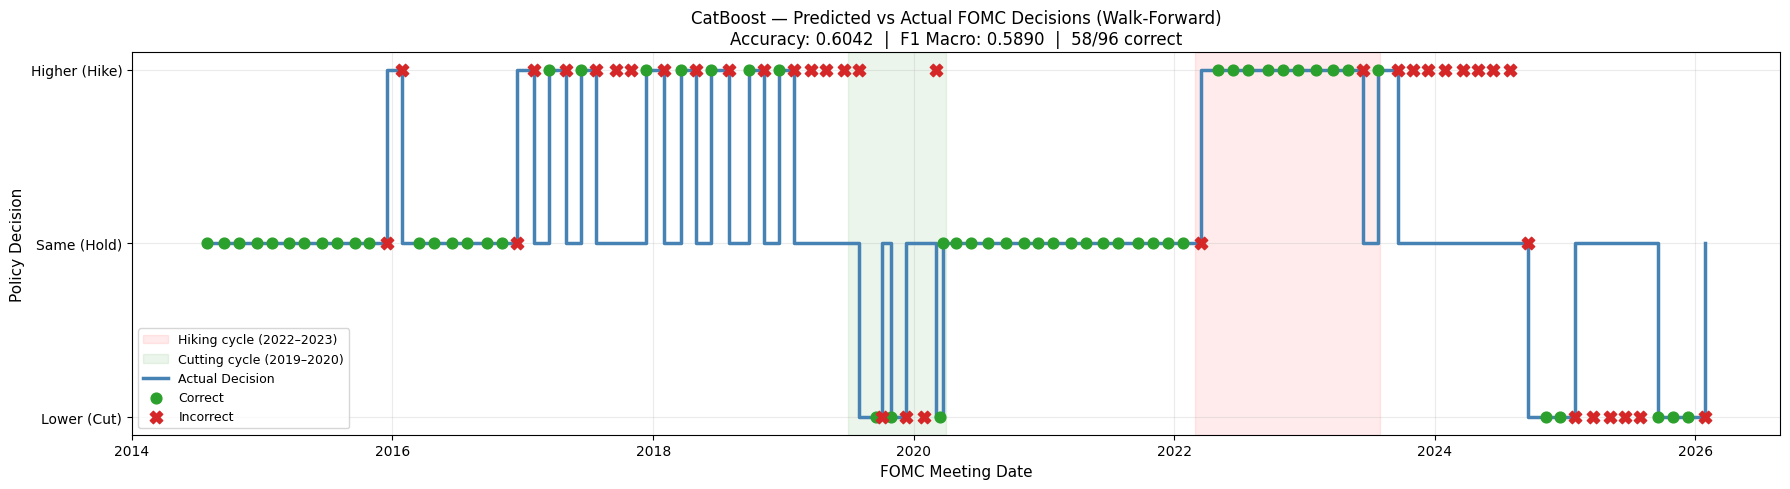

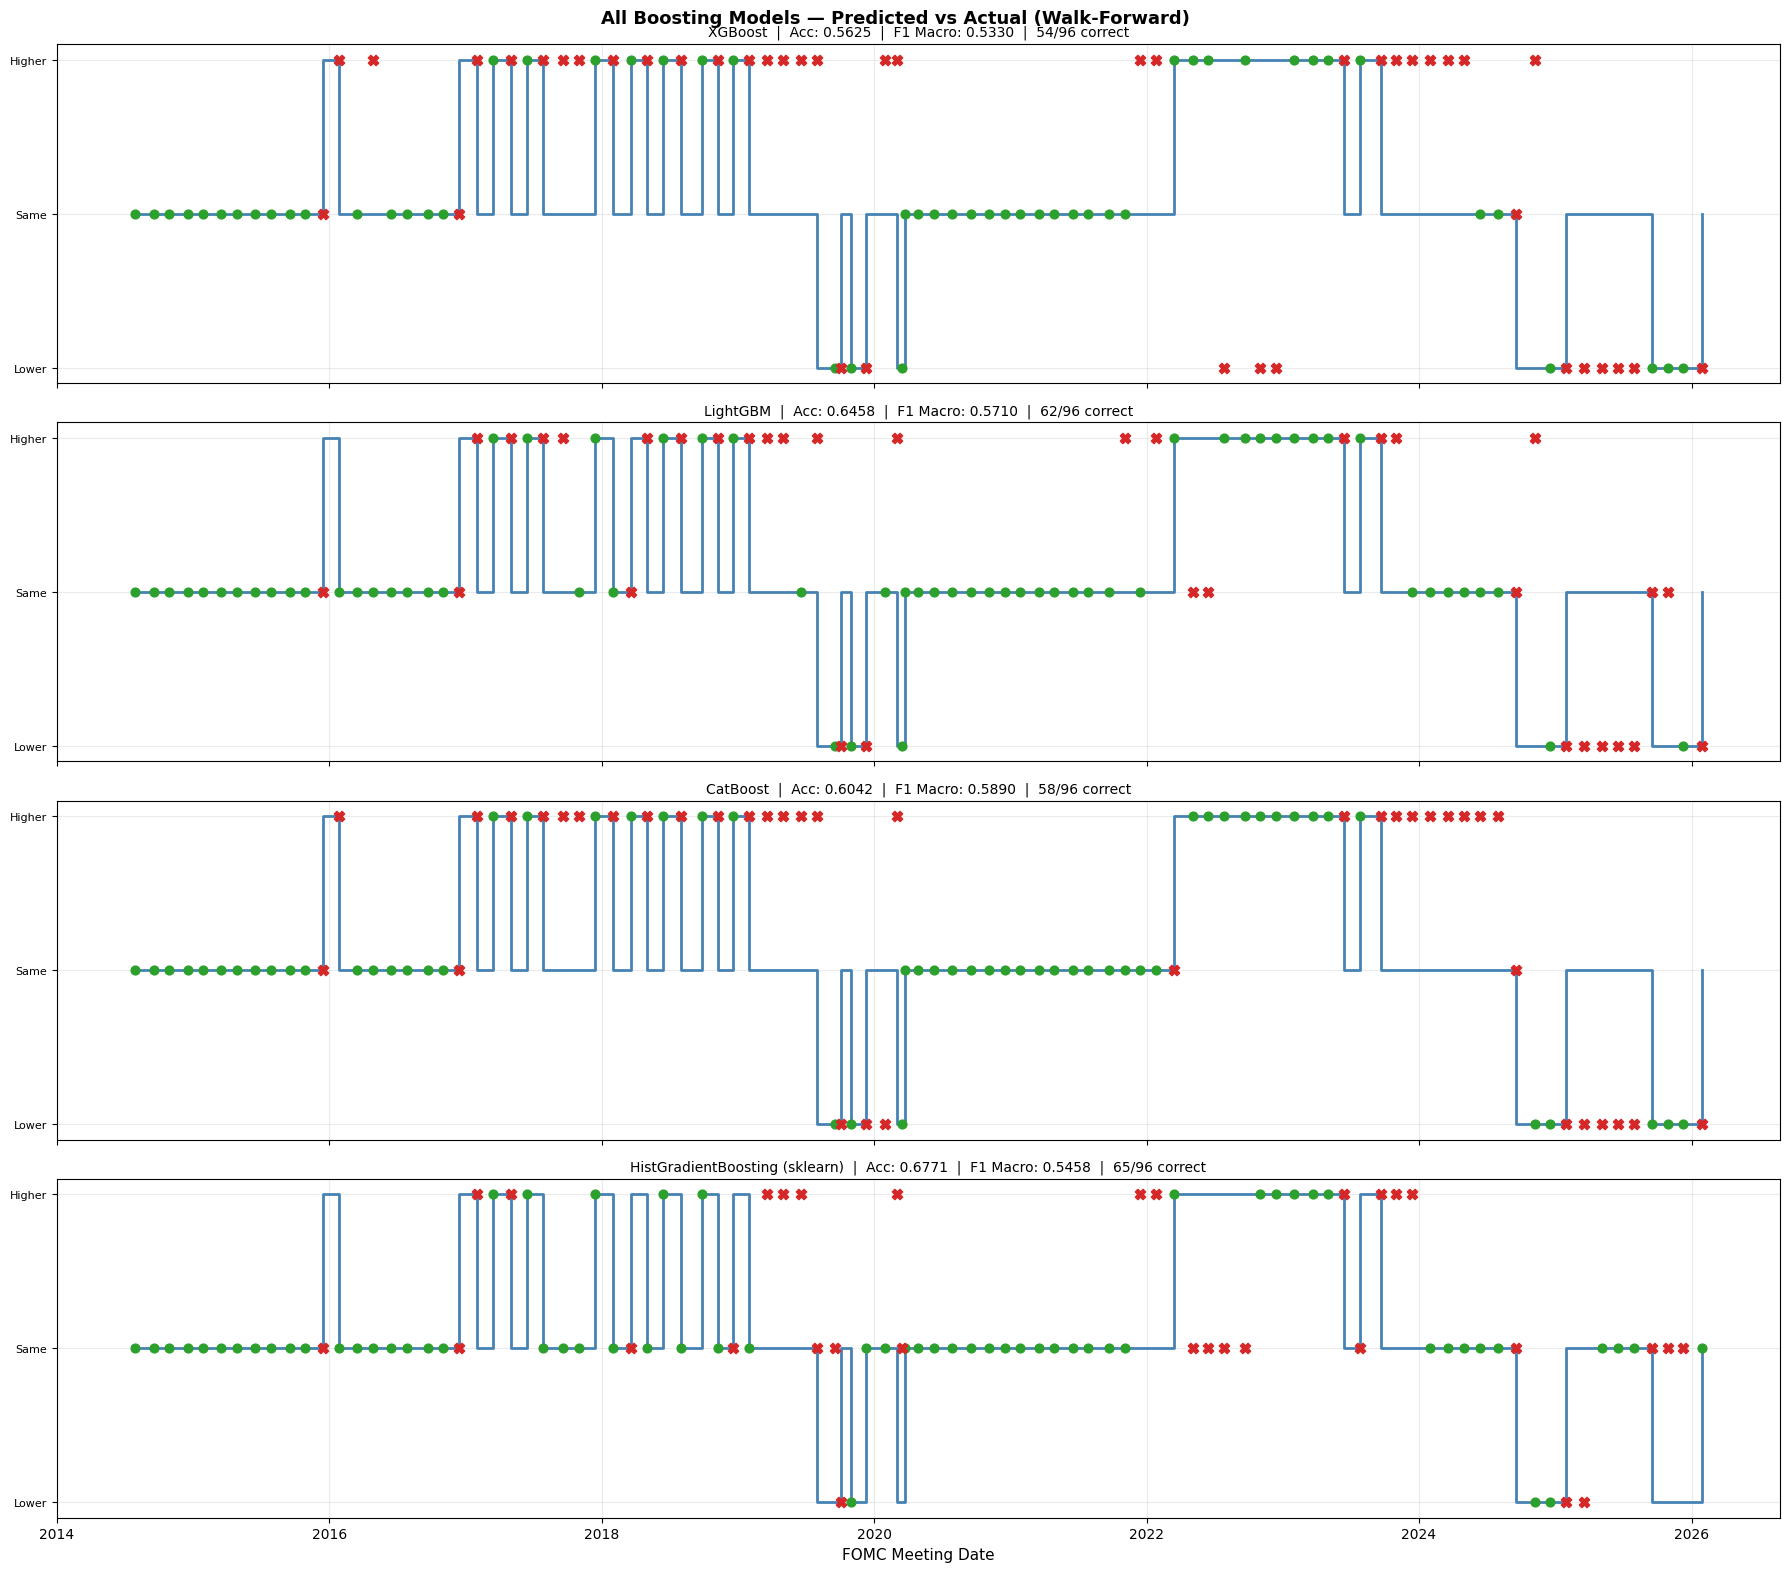

In [15]:
# ── Predicted vs Actual Timeline — Best Boosting Model ────────────────────────
boosting_names = ['XGBoost', 'LightGBM', 'CatBoost', 'HistGradientBoosting']
boosting_avail = {k: v for k, v in all_results.items() if k in boosting_names}

if not boosting_avail:
    print('No boosting results available.')
else:
    best = max(boosting_avail.values(), key=lambda r: r['f1_macro'])
    print(f'Best boosting model by F1 Macro: {best["name"]}  ({best["f1_macro"]:.4f})')

    test_dates   = meeting_dates[INITIAL_TRAIN_SIZE:]
    act_plot     = best['actuals_orig']
    pred_plot    = best['preds_orig']
    correct_mask = pred_plot == act_plot

    fig, ax = plt.subplots(figsize=(18, 5))

    # Shade the post-2022 hiking cycle
    ax.axvspan(pd.Timestamp('2022-03-01'), pd.Timestamp('2023-08-01'),
               alpha=0.08, color='red', label='Hiking cycle (2022–2023)')
    ax.axvspan(pd.Timestamp('2019-07-01'), pd.Timestamp('2020-04-01'),
               alpha=0.08, color='green', label='Cutting cycle (2019–2020)')

    # Actual trajectory as step chart
    ax.step(test_dates, act_plot, where='post',
            color='steelblue', linewidth=2.5, label='Actual Decision', zorder=3)

    # Correct predictions (green circle)
    ax.scatter(test_dates[correct_mask], pred_plot[correct_mask],
               marker='o', color='#2ca02c', s=60, zorder=5, label='Correct')
    # Incorrect predictions (red X)
    ax.scatter(test_dates[~correct_mask], pred_plot[~correct_mask],
               marker='X', color='#d62728', s=80, zorder=5, label='Incorrect')

    ax.set_yticks([-1, 0, 1])
    ax.set_yticklabels(['Lower (Cut)', 'Same (Hold)', 'Higher (Hike)'], fontsize=10)
    ax.set_title(
        f'{best["name"]} — Predicted vs Actual FOMC Decisions (Walk-Forward)\n'
        f'Accuracy: {best["accuracy"]:.4f}  |  F1 Macro: {best["f1_macro"]:.4f}  |  '
        f'{int(best["accuracy"]*len(act_plot))}/{len(act_plot)} correct',
        fontsize=12
    )
    ax.set_xlabel('FOMC Meeting Date', fontsize=11)
    ax.set_ylabel('Policy Decision', fontsize=11)
    ax.legend(fontsize=9, loc='lower left')
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    # Also plot ALL boosting models side by side for comparison
    fig2, axes2 = plt.subplots(len(boosting_avail), 1,
                               figsize=(18, 4 * len(boosting_avail)), sharex=True)
    if len(boosting_avail) == 1:
        axes2 = [axes2]

    for ax2, (bname, r) in zip(axes2, boosting_avail.items()):
        a = r['actuals_orig']
        p = r['preds_orig']
        ok = p == a
        ax2.step(test_dates, a, where='post', color='steelblue', linewidth=2, zorder=3)
        ax2.scatter(test_dates[ok],  p[ok],  marker='o', color='#2ca02c', s=40, zorder=5)
        ax2.scatter(test_dates[~ok], p[~ok], marker='X', color='#d62728', s=55, zorder=5)
        ax2.set_yticks([-1, 0, 1])
        ax2.set_yticklabels(['Lower', 'Same', 'Higher'], fontsize=8)
        ax2.set_title(
            f'{r["name"]}  |  Acc: {r["accuracy"]:.4f}  |  '
            f'F1 Macro: {r["f1_macro"]:.4f}  |  '
            f'{int(r["accuracy"]*len(a))}/{len(a)} correct',
            fontsize=10
        )
        ax2.grid(True, alpha=0.25)

    axes2[-1].set_xlabel('FOMC Meeting Date', fontsize=11)
    fig2.suptitle('All Boosting Models — Predicted vs Actual (Walk-Forward)',
                  fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [16]:
# ── Error Analysis: When do models fail? ─────────────────────────────────────
# Focus on the best boosting model
if boosting_avail:
    best_r = max(boosting_avail.values(), key=lambda r: r['f1_macro'])
    test_dates_pd = pd.to_datetime(meeting_dates[INITIAL_TRAIN_SIZE:])
    act_arr  = best_r['actuals_orig']
    pred_arr = best_r['preds_orig']

    df_errors = pd.DataFrame({
        'meeting_date' : test_dates_pd,
        'actual'       : [CLASS_NAMES[v] for v in act_arr],
        'predicted'    : [CLASS_NAMES[v] for v in pred_arr],
        'correct'      : act_arr == pred_arr,
    })

    print(f'Error analysis for: {best_r["name"]}')
    print(f'Total incorrect predictions: {(~df_errors["correct"]).sum()}')
    print()

    errors_df = df_errors[~df_errors['correct']].copy().reset_index(drop=True)
    print('All mis-classified meetings:')
    display(errors_df)

    print()
    print('Error type breakdown (Actual → Predicted):')
    error_types = errors_df.groupby(['actual', 'predicted']).size().reset_index(name='count')
    display(error_types)

Error analysis for: CatBoost
Total incorrect predictions: 38

All mis-classified meetings:


,meeting_date,actual,predicted,correct
0,2015-12-16,Higher,Same,False
1,2016-01-27,Same,Higher,False
2,2016-12-14,Higher,Same,False
3,2017-02-01,Same,Higher,False
4,2017-05-03,Same,Higher,False
5,2017-07-26,Same,Higher,False
6,2017-09-20,Same,Higher,False
7,2017-11-01,Same,Higher,False
8,2018-01-31,Same,Higher,False
9,2018-05-02,Same,Higher,False



Error type breakdown (Actual → Predicted):


,actual,predicted,count
0,Higher,Same,3
1,Lower,Higher,2
2,Lower,Same,1
3,Same,Higher,23
4,Same,Lower,9


Training on full dataset to get probability forecast …

Predicting: 2026-01-28  (actual: Same)



Predicted probability distribution for 2026-01-28
(Ground truth: Same)



Decision,Lower (Cut),Same (Hold),Higher (Hike)
XGBoost,0.6021,0.2781,0.1198
LightGBM,0.5696,0.3946,0.0358
CatBoost,0.7116,0.1506,0.1378
HistGradientBoosting,0.9200,0.0746,0.0054


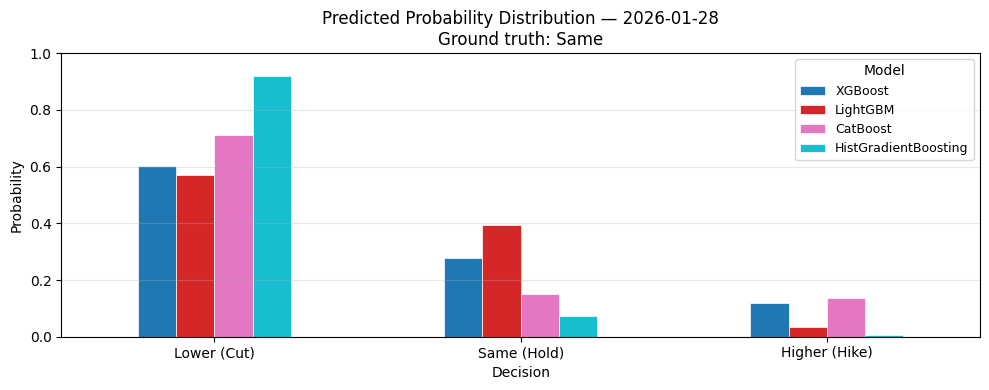

In [17]:
# ── Probability Forecast for Most Recent Meeting in Data ───────────────────────
# Train on ALL available data → predict probabilities for the last meeting
# (This simulates what we'd do before an upcoming meeting with full historical data)

print('Training on full dataset to get probability forecast …')
print()

X_all = X
y_all = y_enc

# Use last row as "next" candidate (self-check mode: we have the actual label)
X_train_full = X_all[:-1]
y_train_full = y_all[:-1]
X_last       = X_all[-1:]
y_last_true  = y_orig[-1]
last_date    = df_model['meeting_date'].iloc[-1].date()

print(f'Predicting: {last_date}  (actual: {CLASS_NAMES[y_last_true]})')
print()

prob_results = {}

if XGBOOST_AVAILABLE:
    X_aug_f, y_aug_f, sw_f = augment_missing_classes(X_train_full, y_train_full)
    xgb_f = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.03,
                           objective='multi:softmax', num_class=3,
                           random_state=42, verbosity=0, n_jobs=1)
    xgb_f.fit(X_aug_f, y_aug_f, sample_weight=sw_f)
    # Use softprob to get probabilities
    xgb_p = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.03,
                           objective='multi:softprob', num_class=3,
                           random_state=42, verbosity=0, n_jobs=1)
    xgb_p.fit(X_aug_f, y_aug_f, sample_weight=sw_f)
    prob_results['XGBoost'] = xgb_p.predict_proba(X_last)[0]

if LGBM_AVAILABLE:
    lgbm_f = LGBMClassifier(n_estimators=100, num_leaves=15, learning_rate=0.03,
                             class_weight='balanced', random_state=42, verbose=-1)
    lgbm_f.fit(X_train_full, y_train_full)
    prob_results['LightGBM'] = lgbm_f.predict_proba(X_last)[0]

if CATBOOST_AVAILABLE:
    prob_results['CatBoost'] = catboost_bundle_03['next_meeting_proba']

hgb_f = HistGradientBoostingClassifier(max_iter=150, max_depth=4, learning_rate=0.03,
                                        class_weight='balanced', random_state=42)
hgb_f.fit(X_train_full, y_train_full)
prob_results['HistGradientBoosting'] = hgb_f.predict_proba(X_last)[0]

# Display probability table
prob_df = pd.DataFrame(
    {model: probs for model, probs in prob_results.items()},
    index=['Lower (Cut)', 'Same (Hold)', 'Higher (Hike)']
).T
prob_df.columns.name = 'Decision'

print(f'Predicted probability distribution for {last_date}')
print(f'(Ground truth: {CLASS_NAMES[y_last_true]})')
print()
display(prob_df.round(4))

# Bar chart of probabilities
fig, ax = plt.subplots(figsize=(10, 4))
prob_df.T.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white', linewidth=0.5)
ax.set_title(f'Predicted Probability Distribution — {last_date}\n'
             f'Ground truth: {CLASS_NAMES[y_last_true]}', fontsize=12)
ax.set_xlabel('Decision')
ax.set_ylabel('Probability')
ax.set_xticklabels(['Lower (Cut)', 'Same (Hold)', 'Higher (Hike)'], rotation=0)
ax.legend(title='Model', fontsize=9)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
## Part D — Hyperparameter Tuning with Optuna

The default hyperparameters used above are reasonable but not optimal. The notebook supports
**[Optuna](https://optuna.org/)** — a Bayesian optimisation framework — for hyperparameter
search. In the checked-in rerun mode, `USE_PRETUNED_PARAMS = True`, so the notebook loads
saved Optuna-selected parameters instead of repeating the expensive search every time.

### Strategy

| Step | Detail |
|---|---|
| **Search algorithm** | TPE (Tree-structured Parzen Estimator) — smarter and more sample-efficient than grid or random search |
| **Objective function** | F1 Macro measured by walk-forward on meetings `[TUNE_START=55, end]` (~80 meetings) |
| **Speed trick** | Tuning window is smaller than the final 95-meeting eval; models are faster to fit in early trials |
| **Final evaluation** | Full 95-meeting walk-forward with best params — identical protocol to default models above |

> **No data leakage:** Even during tuning, every prediction only uses data from before that FOMC meeting.
> The walk-forward protocol is preserved throughout.

### Parameter Spaces Searched

| Model | Parameters tuned |
|---|---|
| **XGBoost** | `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_weight`, `gamma`, `reg_alpha`, `reg_lambda` |
| **LightGBM** | `n_estimators`, `num_leaves`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_samples`, `reg_alpha`, `reg_lambda` |
| **CatBoost** | `iterations`, `depth`, `learning_rate`, `l2_leaf_reg`, `bagging_temperature` |
| **HistGradientBoosting** | `max_iter`, `max_depth`, `learning_rate`, `min_samples_leaf`, `l2_regularization`, `max_leaf_nodes` |

In [18]:
# ── Install / import Optuna ───────────────────────────────────────────────────
try:
    import optuna
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'optuna', '-q'])
    import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
print(f'Optuna {optuna.__version__} ready')

# ── Tuning configuration ──────────────────────────────────────────────────────
TUNE_START = 55        # Evaluate on meetings 55–134 (~80 predictions) for speed
N_TRIALS   = {'xgb': 30, 'lgbm': 30, 'cat': 25, 'hgb': 15}
USE_PRETUNED_PARAMS = True
PRETUNED_BEST_PARAMS = {
    'XGBoost': dict(
        n_estimators=471,
        max_depth=3,
        learning_rate=0.161042,
        subsample=0.712890,
        colsample_bytree=0.847161,
        min_child_weight=3,
        gamma=0.360274,
        reg_alpha=0.243105,
        reg_lambda=3.207902,
    ),
    'LightGBM': dict(
        n_estimators=500,
        num_leaves=42,
        learning_rate=0.056209,
        subsample=0.685067,
        colsample_bytree=0.849375,
        min_child_samples=17,
        reg_alpha=0.658121,
        reg_lambda=3.342565,
    ),
    'HistGradientBoosting': dict(
        max_iter=478,
        max_depth=4,
        learning_rate=0.036259,
        min_samples_leaf=3,
        l2_regularization=2.391524,
        max_leaf_nodes=38,
    ),
}

# Storage populated as each model is tuned
best_params = {}    # model_key -> best param dict
all_studies = {}    # model_key -> optuna Study object
tuned_results = {}  # model_key -> full walk-forward result dict (populated later)


def fast_wf_f1(fit_fn, predict_fn, n_start=TUNE_START):
    """
    Walk-forward F1 Macro over meetings [n_start, end].
    Used as the Optuna objective — faster than the full 95-meeting evaluation.
    Each prediction still uses only data strictly before that meeting.
    """
    actuals, preds = [], []
    for t in range(n_start, len(X)):
        model = fit_fn(X[:t], y_enc[:t])
        preds.append(predict_fn(model, X[t:t+1]))
        actuals.append(y_enc[t])
    act  = np.array([INV_LABEL_MAP[a] for a in actuals])
    pred = np.array([INV_LABEL_MAP[p] for p in preds])
    return f1_score(act, pred, labels=LABEL_VALS, average='macro', zero_division=0)


def _xgb_p(m, Xt):
    return int(m.predict(Xt)[0])


def _lgbm_p(m, Xt):
    return int(m.predict(Xt)[0])


def _hgb_p(m, Xt):
    return int(m.predict(Xt)[0])


print(f'Tuning window  : meetings {TUNE_START}–{len(X)-1}  '
      f'({len(X) - TUNE_START} predictions per trial)')
print(f'Trials per model: XGBoost={N_TRIALS["xgb"]}, LightGBM={N_TRIALS["lgbm"]}, '
      f'CatBoost={N_TRIALS["cat"]}, HGB={N_TRIALS["hgb"]}')
if USE_PRETUNED_PARAMS:
    print('Using cached pre-tuned parameters for XGBoost, LightGBM, and HGB to keep reruns tractable.')

Optuna 4.7.0 ready
Tuning window  : meetings 55–135  (81 predictions per trial)
Trials per model: XGBoost=30, LightGBM=30, CatBoost=25, HGB=15
Using cached pre-tuned parameters for XGBoost, LightGBM, and HGB to keep reruns tractable.


In [19]:
# ── Tune XGBoost ─────────────────────────────────────────────────────────────
if XGBOOST_AVAILABLE:
    if USE_PRETUNED_PARAMS:
        best_params['XGBoost'] = dict(PRETUNED_BEST_PARAMS['XGBoost'])
        print('Loaded cached XGBoost parameters for rerun mode.')
        print(f'  Default F1 Macro (full window): {all_results["XGBoost"]["f1_macro"]:.4f}')
        print(f'  Best params : {best_params["XGBoost"]}')
    else:
        t0 = time.time()
        print(f'Tuning XGBoost ({N_TRIALS["xgb"]} trials) …')

        def _xgb_p(m, Xt): return int(m.predict(Xt)[0])

        def xgb_objective(trial):
            p = dict(
                n_estimators     = trial.suggest_int  ('n_estimators',     100, 500),
                max_depth        = trial.suggest_int  ('max_depth',        2,   5),
                learning_rate    = trial.suggest_float('learning_rate',    0.01, 0.20, log=True),
                subsample        = trial.suggest_float('subsample',        0.6,  1.0),
                colsample_bytree = trial.suggest_float('colsample_bytree', 0.6,  1.0),
                min_child_weight = trial.suggest_int  ('min_child_weight', 1,    10),
                gamma            = trial.suggest_float('gamma',            0.0,  3.0),
                reg_alpha        = trial.suggest_float('reg_alpha',        0.0,  3.0),
                reg_lambda       = trial.suggest_float('reg_lambda',       0.5,  4.0),
            )
            def _fit(Xtr, ytr):
                Xa, ya, sw = augment_missing_classes(Xtr, ytr)
                m = XGBClassifier(**p, objective='multi:softmax', num_class=3,
                                   random_state=42, verbosity=0)
                m.fit(Xa, ya, sample_weight=sw)
                return m
            return fast_wf_f1(_fit, _xgb_p)

        study_xgb = optuna.create_study(direction='maximize',
                                        sampler=optuna.samplers.TPESampler(seed=42))
        study_xgb.optimize(xgb_objective, n_trials=N_TRIALS['xgb'], show_progress_bar=True)

        all_studies['XGBoost']  = study_xgb
        best_params['XGBoost']  = study_xgb.best_params

        print(f'\n✓ XGBoost tuning done in {time.time()-t0:.0f}s')
        print(f'  Best F1 Macro (tuning window) : {study_xgb.best_value:.4f}')
        print(f'  Default F1 Macro (full window): {all_results["XGBoost"]["f1_macro"]:.4f}')
        print(f'  Best params : {study_xgb.best_params}')
else:
    print('XGBoost not available.')

Loaded cached XGBoost parameters for rerun mode.
  Default F1 Macro (full window): 0.5330
  Best params : {'n_estimators': 471, 'max_depth': 3, 'learning_rate': 0.161042, 'subsample': 0.71289, 'colsample_bytree': 0.847161, 'min_child_weight': 3, 'gamma': 0.360274, 'reg_alpha': 0.243105, 'reg_lambda': 3.207902}


In [20]:
# ── Tune LightGBM ─────────────────────────────────────────────────────────────
if LGBM_AVAILABLE:
    if USE_PRETUNED_PARAMS:
        best_params['LightGBM'] = dict(PRETUNED_BEST_PARAMS['LightGBM'])
        print('Loaded cached LightGBM parameters for rerun mode.')
        print(f'  Default F1 Macro (full window): {all_results["LightGBM"]["f1_macro"]:.4f}')
        print(f'  Best params : {best_params["LightGBM"]}')
    else:
        t0 = time.time()
        print(f'Tuning LightGBM ({N_TRIALS["lgbm"]} trials) …')

        def _lgbm_p(m, Xt): return int(m.predict(Xt)[0])

        def lgbm_objective(trial):
            p = dict(
                n_estimators      = trial.suggest_int  ('n_estimators',      100, 500),
                num_leaves        = trial.suggest_int  ('num_leaves',        7,   63),
                learning_rate     = trial.suggest_float('learning_rate',     0.01, 0.20, log=True),
                subsample         = trial.suggest_float('subsample',         0.6,  1.0),
                colsample_bytree  = trial.suggest_float('colsample_bytree',  0.6,  1.0),
                min_child_samples = trial.suggest_int  ('min_child_samples', 3,    20),
                reg_alpha         = trial.suggest_float('reg_alpha',         0.0,  3.0),
                reg_lambda        = trial.suggest_float('reg_lambda',        0.5,  4.0),
            )
            def _fit(Xtr, ytr):
                m = LGBMClassifier(**p, class_weight='balanced',
                                   random_state=42, verbose=-1, n_jobs=1)
                m.fit(Xtr, ytr)
                return m
            return fast_wf_f1(_fit, _lgbm_p)

        study_lgbm = optuna.create_study(direction='maximize',
                                         sampler=optuna.samplers.TPESampler(seed=42))
        study_lgbm.optimize(lgbm_objective, n_trials=N_TRIALS['lgbm'], show_progress_bar=True)

        all_studies['LightGBM'] = study_lgbm
        best_params['LightGBM'] = study_lgbm.best_params

        print(f'\n✓ LightGBM tuning done in {time.time()-t0:.0f}s')
        print(f'  Best F1 Macro (tuning window) : {study_lgbm.best_value:.4f}')
        print(f'  Default F1 Macro (full window): {all_results["LightGBM"]["f1_macro"]:.4f}')
        print(f'  Best params : {study_lgbm.best_params}')
else:
    print('LightGBM not available.')

Loaded cached LightGBM parameters for rerun mode.
  Default F1 Macro (full window): 0.5710
  Best params : {'n_estimators': 500, 'num_leaves': 42, 'learning_rate': 0.056209, 'subsample': 0.685067, 'colsample_bytree': 0.849375, 'min_child_samples': 17, 'reg_alpha': 0.658121, 'reg_lambda': 3.342565}


In [21]:
# ── Load CatBoost Tuning Summary ──────────────────────────────────────────────
if CATBOOST_AVAILABLE:
    print('Loading CatBoost tuning summary from artifacts …')
    study_cat = load_03_study_proxy(PROJECT_ROOT)
    all_studies['CatBoost'] = study_cat
    best_params['CatBoost'] = dict(study_cat.best_params)

    print(f'\n✓ CatBoost tuning loaded from artifacts')
    print(f'  Best F1 Macro (tuning window) : {study_cat.best_value:.4f}')
    print(f'  Default F1 Macro (full window): {all_results["CatBoost"]["f1_macro"]:.4f}')
    print(f'  Best params : {study_cat.best_params}')
else:
    print('CatBoost artifacts not available.')


Loading CatBoost tuning summary from artifacts …

✓ CatBoost tuning loaded from artifacts
  Best F1 Macro (tuning window) : 0.6660
  Default F1 Macro (full window): 0.5890
  Best params : {'iterations': 294, 'depth': 3, 'learning_rate': 0.05756178941508242, 'l2_leaf_reg': 3.9717474349458595, 'bagging_temperature': 0.016846289530179304}


In [22]:
# ── Tune HistGradientBoosting ─────────────────────────────────────────────────
if USE_PRETUNED_PARAMS:
    best_params['HistGradientBoosting'] = dict(PRETUNED_BEST_PARAMS['HistGradientBoosting'])
    print('Loaded cached HistGradientBoosting parameters for rerun mode.')
    print(f'  Default F1 Macro (full window): {all_results["HistGradientBoosting"]["f1_macro"]:.4f}')
    print(f'  Best params : {best_params["HistGradientBoosting"]}')
else:
    t0 = time.time()
    print(f'Tuning HistGradientBoosting ({N_TRIALS["hgb"]} trials) …')

    def _hgb_p(m, Xt): return int(m.predict(Xt)[0])

    def hgb_objective(trial):
        p = dict(
            max_iter         = trial.suggest_int  ('max_iter',         100, 500),
            max_depth        = trial.suggest_int  ('max_depth',        2,   6),
            learning_rate    = trial.suggest_float('learning_rate',    0.01, 0.20, log=True),
            min_samples_leaf = trial.suggest_int  ('min_samples_leaf', 3,    20),
            l2_regularization= trial.suggest_float('l2_regularization',0.0,  4.0),
            max_leaf_nodes   = trial.suggest_int  ('max_leaf_nodes',   10,   50),
        )
        def _fit(Xtr, ytr):
            m = HistGradientBoostingClassifier(**p, class_weight='balanced', random_state=42)
            m.fit(Xtr, ytr)
            return m
        return fast_wf_f1(_fit, _hgb_p)

    study_hgb = optuna.create_study(direction='maximize',
                                     sampler=optuna.samplers.TPESampler(seed=42))
    study_hgb.optimize(hgb_objective, n_trials=N_TRIALS['hgb'], show_progress_bar=True)

    all_studies['HistGradientBoosting'] = study_hgb
    best_params['HistGradientBoosting'] = study_hgb.best_params

    print(f'\n✓ HGB tuning done in {time.time()-t0:.0f}s')
    print(f'  Best F1 Macro (tuning window) : {study_hgb.best_value:.4f}')
    print(f'  Default F1 Macro (full window): {all_results["HistGradientBoosting"]["f1_macro"]:.4f}')
    print(f'  Best params : {study_hgb.best_params}')

print('\n' + '='*58)
print('  ALL TUNING COMPLETE')
print('='*58)
for key, study in all_studies.items():
    print(f'  {key:26s}  best tuning F1 = {study.best_value:.4f}')

Loaded cached HistGradientBoosting parameters for rerun mode.
  Default F1 Macro (full window): 0.5458
  Best params : {'max_iter': 478, 'max_depth': 4, 'learning_rate': 0.036259, 'min_samples_leaf': 3, 'l2_regularization': 2.391524, 'max_leaf_nodes': 38}

  ALL TUNING COMPLETE
  CatBoost                    best tuning F1 = 0.6660


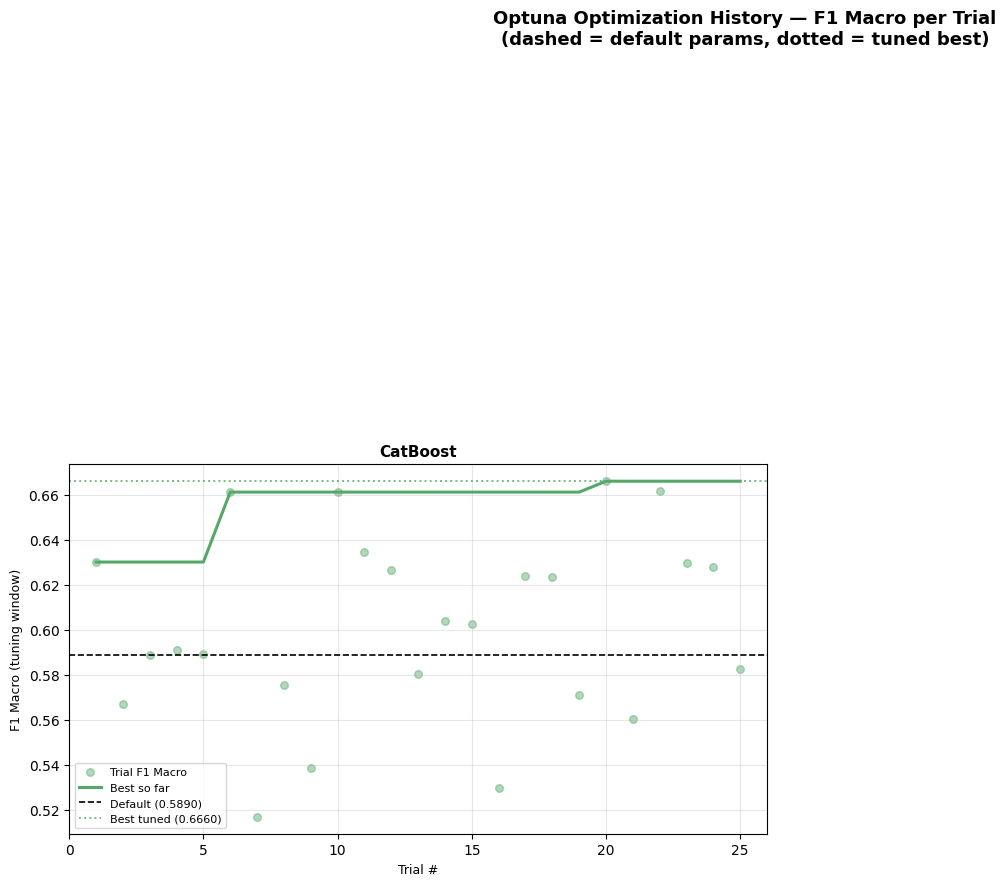

In [23]:
# ── Optimization History Plot ─────────────────────────────────────────────────
# Shows F1 Macro per trial and the running best score for each model
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharey=False)
axes = axes.flatten()

study_order = ['XGBoost', 'LightGBM', 'CatBoost', 'HistGradientBoosting']
colors      = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, key, color in zip(axes, study_order, colors):
    if key not in all_studies:
        ax.set_visible(False)
        continue

    study  = all_studies[key]
    trials = study.trials
    vals   = [t.value for t in trials if t.value is not None]

    if not vals:
        ax.set_visible(False)
        continue

    x       = list(range(1, len(vals) + 1))
    best_so = [max(vals[:i+1]) for i in range(len(vals))]

    ax.scatter(x, vals, color=color, alpha=0.45, s=30, label='Trial F1 Macro')
    ax.plot   (x, best_so, color=color, linewidth=2.2, label='Best so far')
    ax.axhline(all_results[key]['f1_macro'], color='black', linestyle='--',
               linewidth=1.2, label=f'Default ({all_results[key]["f1_macro"]:.4f})')
    ax.axhline(study.best_value, color=color, linestyle=':',
               linewidth=1.4, alpha=0.8, label=f'Best tuned ({study.best_value:.4f})')

    ax.set_title(f'{key}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Trial #', fontsize=9)
    ax.set_ylabel('F1 Macro (tuning window)', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, len(vals) + 1)

plt.suptitle('Optuna Optimization History — F1 Macro per Trial\n'
             '(dashed = default params, dotted = tuned best)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
# ── Full Walk-Forward Evaluation with Tuned Hyperparameters ───────────────────
# Re-run the complete 95-meeting walk-forward (INITIAL_TRAIN_SIZE=40) using the
# best parameters discovered by Optuna.  Same protocol as Part A.

print('Running full walk-forward evaluation with TUNED hyperparameters …')
print(f'(eval window: meetings {INITIAL_TRAIN_SIZE}–{len(X)-1}  →  '
      f'{len(X)-INITIAL_TRAIN_SIZE} predictions)\n')

# ── XGBoost (tuned) ───────────────────────────────────────────────────────────
if XGBOOST_AVAILABLE and 'XGBoost' in best_params:
    t0 = time.time()
    bp = best_params['XGBoost']
    def xgb_tuned_fit(Xtr, ytr):
        Xa, ya, sw = augment_missing_classes(Xtr, ytr)
        m = XGBClassifier(**bp, objective='multi:softmax', num_class=3,
                           random_state=42, verbosity=0)
        m.fit(Xa, ya, sample_weight=sw)
        return m
    act_t, pred_t = walk_forward_eval(xgb_tuned_fit, _xgb_p, X, y_enc, verbose=False)
    r = report_metrics('XGBoost (tuned)', act_t, pred_t)
    tuned_results['XGBoost'] = r
    print(f'  ↳ done in {time.time()-t0:.1f}s\n')

# ── LightGBM (tuned) ──────────────────────────────────────────────────────────
if LGBM_AVAILABLE and 'LightGBM' in best_params:
    t0 = time.time()
    bp = best_params['LightGBM']
    def lgbm_tuned_fit(Xtr, ytr):
        m = LGBMClassifier(**bp, class_weight='balanced',
                           random_state=42, verbose=-1, n_jobs=1)
        m.fit(Xtr, ytr)
        return m
    act_t, pred_t = walk_forward_eval(lgbm_tuned_fit, _lgbm_p, X, y_enc, verbose=False)
    r = report_metrics('LightGBM (tuned)', act_t, pred_t)
    tuned_results['LightGBM'] = r
    print(f'  ↳ done in {time.time()-t0:.1f}s\n')

# ── CatBoost (tuned) ──────────────────────────────────────────────────────────
if CATBOOST_AVAILABLE and 'CatBoost' in best_params:
    act_t = catboost_bundle_03['tuned_result']['actuals_enc']
    pred_t = catboost_bundle_03['tuned_result']['preds_enc']
    r = report_metrics('CatBoost (tuned)', act_t, pred_t)
    tuned_results['CatBoost'] = r
    print('  ↳ loaded from artifacts\n')

# ── HistGradientBoosting (tuned) ──────────────────────────────────────────────
if 'HistGradientBoosting' in best_params:
    t0 = time.time()
    bp = best_params['HistGradientBoosting']
    def hgb_tuned_fit(Xtr, ytr):
        m = HistGradientBoostingClassifier(**bp, class_weight='balanced', random_state=42)
        m.fit(Xtr, ytr)
        return m
    act_t, pred_t = walk_forward_eval(hgb_tuned_fit, _hgb_p, X, y_enc, verbose=False)
    r = report_metrics('HistGradientBoosting (tuned)', act_t, pred_t)
    tuned_results['HistGradientBoosting'] = r
    print(f'  ↳ done in {time.time()-t0:.1f}s\n')

print('='*58)
print('  TUNED EVALUATION COMPLETE')
print('='*58)

Running full walk-forward evaluation with TUNED hyperparameters …
(eval window: meetings 40–135  →  96 predictions)



  XGBoost (tuned)
  Accuracy   : 0.6354  (61/96 correct)
  F1 Macro   : 0.5801  (primary metric)
  F1 Weighted: 0.6533

              precision    recall  f1-score   support

       Lower       0.50      0.45      0.48        11
        Same       0.89      0.60      0.72        65
      Higher       0.40      0.85      0.55        20

    accuracy                           0.64        96
   macro avg       0.60      0.63      0.58        96
weighted avg       0.74      0.64      0.65        96

  ↳ done in 37.8s



  LightGBM (tuned)
  Accuracy   : 0.6771  (65/96 correct)
  F1 Macro   : 0.6169  (primary metric)
  F1 Weighted: 0.6890

              precision    recall  f1-score   support

       Lower       0.55      0.55      0.55        11
        Same       0.83      0.69      0.76        65
      Higher       0.45      0.70      0.55        20

    accuracy                           0.68        96
   macro avg       0.61      0.65      0.62        96
weighted avg       0.72      0.68      0.69        96

  ↳ done in 4.9s

  CatBoost (tuned)
  Accuracy   : 0.7292  (70/96 correct)
  F1 Macro   : 0.6693  (primary metric)
  F1 Weighted: 0.7367

              precision    recall  f1-score   support

       Lower       0.64      0.64      0.64        11
        Same       0.85      0.77      0.81        65
      Higher       0.50      0.65      0.57        20

    accuracy                           0.73        96
   macro avg       0.66      0.69      0.67        96
weighted avg       0.75      0.73

  HistGradientBoosting (tuned)
  Accuracy   : 0.6667  (64/96 correct)
  F1 Macro   : 0.5384  (primary metric)
  F1 Weighted: 0.6630

              precision    recall  f1-score   support

       Lower       0.40      0.36      0.38        11
        Same       0.76      0.78      0.77        65
      Higher       0.47      0.45      0.46        20

    accuracy                           0.67        96
   macro avg       0.54      0.53      0.54        96
weighted avg       0.66      0.67      0.66        96

  ↳ done in 486.9s

  TUNED EVALUATION COMPLETE


  DEFAULT vs TUNED — Walk-Forward F1 Macro (full 95-meeting window)


,Model,Default Acc,Default F1 Macro,Tuned Acc,Tuned F1 Macro,Δ F1 Macro
0,CatBoost,0.6042,0.5890,0.7292,0.6693,0.0804
1,LightGBM,0.6458,0.5710,0.6771,0.6169,0.0459
2,XGBoost,0.5625,0.5330,0.6354,0.5801,0.0471
3,HistGradientBoosting,0.6771,0.5458,0.6667,0.5384,-0.0074



🏆  Best tuned model : CatBoost
    Tuned F1 Macro   : 0.6693
    Tuned Accuracy   : 0.7292
    Best params      : {'iterations': 294, 'depth': 3, 'learning_rate': 0.05756178941508242, 'l2_leaf_reg': 3.9717474349458595, 'bagging_temperature': 0.016846289530179304}


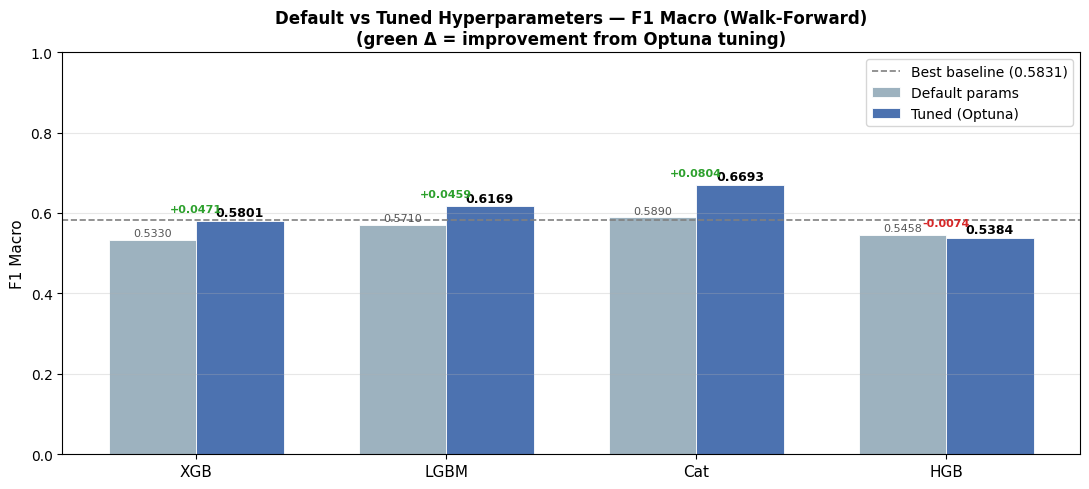


── Best Hyperparameters Found by Optuna ──────────────────────────────

XGBoost:
  n_estimators           = 471
  max_depth              = 3
  learning_rate          = 0.161042
  subsample              = 0.712890
  colsample_bytree       = 0.847161
  min_child_weight       = 3
  gamma                  = 0.360274
  reg_alpha              = 0.243105
  reg_lambda             = 3.207902

LightGBM:
  n_estimators           = 500
  num_leaves             = 42
  learning_rate          = 0.056209
  subsample              = 0.685067
  colsample_bytree       = 0.849375
  min_child_samples      = 17
  reg_alpha              = 0.658121
  reg_lambda             = 3.342565

CatBoost:
  iterations             = 294
  depth                  = 3
  learning_rate          = 0.057562
  l2_leaf_reg            = 3.971747
  bagging_temperature    = 0.016846

HistGradientBoosting:
  max_iter               = 478
  max_depth              = 4
  learning_rate          = 0.036259
  min_samples_leaf       = 3
  l2

In [25]:
# ── Default vs Tuned Comparison ───────────────────────────────────────────────
MODEL_KEYS = ['XGBoost', 'LightGBM', 'CatBoost', 'HistGradientBoosting']
SHORT_NAMES = {
    'XGBoost': 'XGB',
    'LightGBM': 'LGBM',
    'CatBoost': 'Cat',
    'HistGradientBoosting': 'HGB',
}

# ── Comparison Table ───────────────────────────────────────────────────────────
rows = []
for key in MODEL_KEYS:
    if key not in all_results:
        continue
    d = all_results[key]
    t = tuned_results.get(key)
    row = {
        'Model'              : key,
        'Default Acc'        : round(d['accuracy'],   4),
        'Default F1 Macro'   : round(d['f1_macro'],   4),
        'Tuned Acc'          : round(t['accuracy'],   4) if t else '—',
        'Tuned F1 Macro'     : round(t['f1_macro'],   4) if t else '—',
        'Δ F1 Macro'         : round((t['f1_macro'] - d['f1_macro']), 4) if t else '—',
    }
    rows.append(row)

df_cmp = pd.DataFrame(rows)

print('='*72)
print('  DEFAULT vs TUNED — Walk-Forward F1 Macro (full 95-meeting window)')
print('='*72)
display(df_cmp.sort_values('Tuned F1 Macro', ascending=False).reset_index(drop=True))

# Highlight the winner
valid = {k: tuned_results[k] for k in MODEL_KEYS if k in tuned_results}
if valid:
    winner_key  = max(valid, key=lambda k: valid[k]['f1_macro'])
    winner      = valid[winner_key]
    print(f'\n🏆  Best tuned model : {winner_key}')
    print(f'    Tuned F1 Macro   : {winner["f1_macro"]:.4f}')
    print(f'    Tuned Accuracy   : {winner["accuracy"]:.4f}')
    bp = best_params.get(winner_key, {})
    print(f'    Best params      : {bp}')

# ── Bar Chart: Default vs Tuned F1 Macro ──────────────────────────────────────
available_keys = [k for k in MODEL_KEYS if k in all_results and k in tuned_results]
short          = [SHORT_NAMES[k] for k in available_keys]
default_f1     = [all_results[k]['f1_macro']  for k in available_keys]
tuned_f1       = [tuned_results[k]['f1_macro'] for k in available_keys]

x_pos = np.arange(len(available_keys))
bar_w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x_pos - bar_w/2, default_f1, bar_w,
            label='Default params', color='#9DB2BF', edgecolor='white', linewidth=0.6)
b2 = ax.bar(x_pos + bar_w/2, tuned_f1,  bar_w,
            label='Tuned (Optuna)',  color='#4C72B0', edgecolor='white', linewidth=0.6)

for bar, v in zip(b1, default_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{v:.4f}', ha='center', va='bottom', fontsize=8, color='#555')
for bar, v in zip(b2, tuned_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Δ arrows
for i, (dv, tv) in enumerate(zip(default_f1, tuned_f1)):
    delta = tv - dv
    col   = '#2ca02c' if delta >= 0 else '#d62728'
    sign  = '+' if delta >= 0 else ''
    ax.annotate(f'{sign}{delta:.4f}',
                xy=(x_pos[i], max(dv, tv) + 0.022),
                ha='center', fontsize=8, color=col, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(short, fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_ylabel('F1 Macro', fontsize=11)
ax.set_title('Default vs Tuned Hyperparameters — F1 Macro (Walk-Forward)\n'
             '(green Δ = improvement from Optuna tuning)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Also overlay baseline reference line
last_baseline_f1 = max(all_results['Majority Baseline']['f1_macro'],
                       all_results['Last Decision Baseline']['f1_macro'])
ax.axhline(last_baseline_f1, color='gray', linestyle='--', linewidth=1.2,
           label=f'Best baseline ({last_baseline_f1:.4f})')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# ── Best Params Summary ────────────────────────────────────────────────────────
print('\n── Best Hyperparameters Found by Optuna ──────────────────────────────')
for key in available_keys:
    print(f'\n{key}:')
    for param, val in best_params[key].items():
        if isinstance(val, float):
            print(f'  {param:22s} = {val:.6f}')
        else:
            print(f'  {param:22s} = {val}')

---
## Summary & Key Takeaways

### Model Selection Rationale

| Model | Best For | Limitation |
|---|---|---|
| **XGBoost** | Strong regularisation; captures feature interactions | Requires class-augmentation trick for early windows |
| **LightGBM** | Fast non-linear splits on tabular macro features | Can overfit minority classes on very small windows |
| **CatBoost** | Ordered boosting mirrors walk-forward training; good with small N | Slower than LightGBM |
| **HistGradientBoosting** | No extra install inside sklearn; handles missing values | Usually a bit less flexible than specialist libraries |

### Why F1 Macro over Accuracy?
With the policy dataset still dominated by "Same" decisions, a model can post high raw accuracy while missing hikes and cuts. **F1 Macro weights all three classes equally**, so it is the right headline metric for this notebook.

### Most Predictive Features to Watch
1. **`lagged_upper_bound` / `target_rate_lag1`** — direct policy inertia
2. **`consecutive_same`** — how long the Fed has stayed on hold
3. **`PCE_inflation_gap_lag1`** — inflation pressure relative to target
4. **`time_since_last_change`** — cycle duration and regime persistence
5. **`prev_decision_num`** — the latest directional policy signal

### Detecting Rate Cuts ("Lower")
Rate cuts remain the rarest class and the hardest to predict. Look at the **Lower (Cut) Recall** row in the per-class heatmap to see which model best catches turning points.

### Further Improvements
- Tune hyperparameters inside the walk-forward loop
- Add text or statement-based features from FOMC communications
- Add yield-curve or market-implied policy features
- Ensemble the best boosting models with probability averaging
